In [1]:
# Cell 1 — Memory config BEFORE loading anything
import os
import gc
import numpy as np

# Limit TF memory growth
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU: {[g.name for g in gpus]}")

# Force float32 globally (not float64)
tf.keras.backend.set_floatx('float32')
print("✅ float32 set globally")

2026-04-26 00:12:28.356005: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777162348.598590      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777162348.671806      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777162349.258152      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777162349.258213      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777162349.258216      55 computation_placer.cc:177] computation placer alr

✅ GPU: ['/physical_device:GPU:0']
✅ float32 set globally


In [2]:
# Cell 2 — Imports
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix)
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Cell 3 — Load Data (keep as parquet, don't convert yet)
import pandas as pd

TRAIN_PATH = "/kaggle/input/datasets/muhammadasad29/ember-feature-based-dataset/ember/train_ember_2018_final.parquet"
TEST_PATH  = "/kaggle/input/datasets/muhammadasad29/ember-feature-based-dataset/ember/test_ember_2018_final.parquet"

# Load ONLY what you need — keep as pandas (lazy)
train_df = pd.read_parquet(TRAIN_PATH)
test_df  = pd.read_parquet(TEST_PATH)

print(f"Train: {train_df.shape} | Test: {test_df.shape}")
print(f"Train RAM: {train_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Train: (599920, 2342) | Test: (199956, 2342)
Train RAM: 5.62 GB


In [4]:
# Cell 4 — Client Splits (pandas only, no numpy yet)
train_df = train_df.sample(frac=1, random_state=42)

client1_df = train_df.iloc[:int(0.5 * len(train_df))].copy()

client_size = int(0.5 * len(train_df))
malware_df  = train_df[train_df["Label"] == 1].sample(frac=1, random_state=42)
benign_df   = train_df[train_df["Label"] == 0].sample(frac=1, random_state=42)

client2_df = pd.concat([
    malware_df.iloc[:int(0.8 * client_size)],
    benign_df.iloc[:int(0.2 * client_size)]
]).sample(frac=1, random_state=42)

# Free intermediates immediately
del malware_df, benign_df
gc.collect()

print(f"Client 1: {len(client1_df)} | {client1_df['Label'].value_counts().to_dict()}")
print(f"Client 2: {len(client2_df)} | {client2_df['Label'].value_counts().to_dict()}")

Client 1: 299960 | {1: 150078, 0: 149882}
Client 2: 299960 | {1: 239968, 0: 59992}


In [5]:
# Cell 5 — Ultra Memory-Efficient Scaling
import gc
import numpy as np
from sklearn.preprocessing import StandardScaler

# ── Step 1: Fit scaler using partial_fit in chunks
# Never loads full dataset into memory at once
global_scaler = StandardScaler()

CHUNK_SIZE = 50000  # 50K rows at a time

feature_cols = [c for c in train_df.columns if c != "Label"]
n_rows = len(train_df)

for start in range(0, n_rows, CHUNK_SIZE):
    chunk = train_df[feature_cols].iloc[start:start+CHUNK_SIZE].values.astype("float32")
    global_scaler.partial_fit(chunk)
    del chunk
    gc.collect()

print("✅ Scaler fitted via partial_fit (chunk-wise)")

# ── Step 2: Scale + extract clients chunk-wise too
def scale_dataframe(df, scaler, feature_cols, chunk_size=50000):
    """Transform a dataframe in chunks, return float32 numpy array."""
    n = len(df)
    result = np.empty((n, len(feature_cols)), dtype="float32")
    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        chunk = df[feature_cols].iloc[start:end].values.astype("float32")
        result[start:end] = scaler.transform(chunk)
        del chunk
        gc.collect()
    return result

# ── Step 3: Scale test set
X_test_scaled = scale_dataframe(test_df, global_scaler, feature_cols)
y_test = test_df["Label"].values.astype("float32")
del test_df
gc.collect()
print(f"✅ X_test_scaled: {X_test_scaled.shape}")

# ── Step 4: Scale Client 1
X_c1 = scale_dataframe(client1_df, global_scaler, feature_cols)
y_c1 = client1_df["Label"].values.astype("float32")
del client1_df
gc.collect()
print(f"✅ X_c1: {X_c1.shape}")

# ── Step 5: Scale Client 2
X_c2 = scale_dataframe(client2_df, global_scaler, feature_cols)
y_c2 = client2_df["Label"].values.astype("float32")
del client2_df
gc.collect()
print(f"✅ X_c2: {X_c2.shape}")

# ── Step 6: Free train_df
del train_df
gc.collect()

INPUT_DIM = X_c1.shape[1]
print(f"\nInput dim   : {INPUT_DIM}")
print(f"X_c1        : {X_c1.shape}")
print(f"X_c2        : {X_c2.shape}")
print(f"X_test      : {X_test_scaled.shape}")
print("✅ All scaling done — no full matrix copies in memory")

✅ Scaler fitted via partial_fit (chunk-wise)
✅ X_test_scaled: (199956, 2341)
✅ X_c1: (299960, 2341)
✅ X_c2: (299960, 2341)

Input dim   : 2341
X_c1        : (299960, 2341)
X_c2        : (299960, 2341)
X_test      : (199956, 2341)
✅ All scaling done — no full matrix copies in memory


In [6]:
# Cell 6 — Load Pre-Trained Client Models (WARM START)
# Client 1: full MLP
c1_pretrained = load_model("/kaggle/input/models/muhammadasad29/ember/keras/default/1/ember_client1.keras")

# Client 2: MLP only (RF stays local — cannot be federated)
c2_pretrained_mlp = load_model("/kaggle/input/models/muhammadasad29/ember/keras/default/1/ember_client2_mlp.keras")
c2_pretrained_rf  = joblib.load("/kaggle/input/models/muhammadasad29/ember/keras/default/1/ember_client2_rf.pkl")
# ^ RF is loaded but NOT used in FL — Client 2's local advantage only

print("✅ Pre-trained models loaded")
print(f"   Client 1 MLP weights shape check: {c1_pretrained.get_weights()[0].shape}")
print(f"   Client 2 MLP weights shape check: {c2_pretrained_mlp.get_weights()[0].shape}")

I0000 00:00:1777162500.737907      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Pre-trained models loaded
   Client 1 MLP weights shape check: (2341, 512)
   Client 2 MLP weights shape check: (2341, 512)


In [7]:
# Cell 7 — Verify Pre-Trained Baselines on Test Set
print("=" * 60)
print("PRE-TRAINED BASELINES (before FL)")
print("=" * 60)

# Client 1 standalone
c1_prob_pretrained = c1_pretrained.predict(X_test_scaled, verbose=0).ravel()
c1_metrics_pre = {
    'accuracy': accuracy_score(y_test, (c1_prob_pretrained > 0.5).astype(int)),
    'f1':       f1_score(y_test, (c1_prob_pretrained > 0.5).astype(int)),
    'roc_auc':  roc_auc_score(y_test, c1_prob_pretrained)
}
print(f"\n[Client 1 - MLP standalone]")
print(f"  Acc: {c1_metrics_pre['accuracy']:.4f} | F1: {c1_metrics_pre['f1']:.4f} | ROC-AUC: {c1_metrics_pre['roc_auc']:.4f}")

# Client 2 MLP standalone
c2_prob_mlp_pretrained = c2_pretrained_mlp.predict(X_test_scaled, verbose=0).ravel()
c2_metrics_mlp_pre = {
    'accuracy': accuracy_score(y_test, (c2_prob_mlp_pretrained > 0.5).astype(int)),
    'f1':       f1_score(y_test, (c2_prob_mlp_pretrained > 0.5).astype(int)),
    'roc_auc':  roc_auc_score(y_test, c2_prob_mlp_pretrained)
}
print(f"\n[Client 2 - MLP only (FL-eligible part)]")
print(f"  Acc: {c2_metrics_mlp_pre['accuracy']:.4f} | F1: {c2_metrics_mlp_pre['f1']:.4f} | ROC-AUC: {c2_metrics_mlp_pre['roc_auc']:.4f}")

# Client 2 hybrid (local only — for reference)
c2_rf_prob = c2_pretrained_rf.predict_proba(X_test_scaled)[:, 1]
ensemble_prob = (c2_prob_mlp_pretrained + c2_rf_prob) / 2
c2_metrics_hybrid_pre = {
    'accuracy': accuracy_score(y_test, (ensemble_prob > 0.5).astype(int)),
    'f1':       f1_score(y_test, (ensemble_prob > 0.5).astype(int)),
    'roc_auc':  roc_auc_score(y_test, ensemble_prob)
}
print(f"\n[Client 2 - Hybrid MLP+RF (local only, NOT in FL)]")
print(f"  Acc: {c2_metrics_hybrid_pre['accuracy']:.4f} | F1: {c2_metrics_hybrid_pre['f1']:.4f} | ROC-AUC: {c2_metrics_hybrid_pre['roc_auc']:.4f}")

PRE-TRAINED BASELINES (before FL)


I0000 00:00:1777162510.361096     138 service.cc:152] XLA service 0x7ac0b0007f60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777162510.361137     138 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777162510.475348     138 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777162510.873950     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



[Client 1 - MLP standalone]
  Acc: 0.9341 | F1: 0.9345 | ROC-AUC: 0.9823

[Client 2 - MLP only (FL-eligible part)]
  Acc: 0.8590 | F1: 0.8753 | ROC-AUC: 0.9759

[Client 2 - Hybrid MLP+RF (local only, NOT in FL)]
  Acc: 0.8493 | F1: 0.8680 | ROC-AUC: 0.9733


In [8]:
# Cell 8 — FedAvg Core Functions
def build_mlp(input_dim):
    """Same architecture used by both clients."""
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(512, activation='relu'),
        Dropout(0.3),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


def fedavg(weights_list, data_sizes):
    """
    Weighted average of model weights proportional to local dataset size.
    Only model weights travel to the server — no raw data.
    """
    total = sum(data_sizes)
    averaged = []
    for layer_weights in zip(*weights_list):
        avg = sum(w * (n / total) for w, n in zip(layer_weights, data_sizes))
        averaged.append(avg)
    return averaged


def client_update(global_weights, X_train, y_train,
                  local_epochs=3, batch_size=512):
    """
    Client receives global weights, fine-tunes on local private data,
    returns updated weights only. Raw data never leaves.
    """
    model = build_mlp(X_train.shape[1])
    model.set_weights(global_weights)            # apply global model
    es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    model.fit(
        X_train, y_train,
        epochs=local_epochs,
        batch_size=batch_size,
        validation_split=0.1,
        callbacks=[es],
        verbose=0
    )
    return model.get_weights()                   # only weights go to server


def evaluate_weights(weights, X_test, y_test):
    model = build_mlp(X_test.shape[1])
    model.set_weights(weights)
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype(int)
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1':       f1_score(y_test, y_pred),
        'roc_auc':  roc_auc_score(y_test, y_prob)
    }

In [11]:
# Cell 9 — Warm Start + Hyperparameters

# ── Hyperparameters (MUST be defined before Cell 10)
NUM_ROUNDS   = 10
LOCAL_EPOCHS = 3
DATA_SIZES   = [len(X_c1), len(X_c2)]

# ── Reset tracking variables
history        = []
best_f1        = 0.0
best_weights   = None
best_round_num = 0

print("=" * 60)
print("Round 0: Warm start from Client-1 pre-trained weights")
print("=" * 60)

# Use Client-1 as init (avoids misaligned weight averaging issue)
global_weights = [w.copy() for w in c1_pretrained.get_weights()]

m0 = evaluate_weights(global_weights, X_test_scaled, y_test)
history.append({'round': 0, **m0})

print(f"  [Global Round 0]  Acc: {m0['accuracy']:.4f} | "
      f"F1: {m0['f1']:.4f} | "
      f"ROC-AUC: {m0['roc_auc']:.4f}")
print(f"\nNUM_ROUNDS   = {NUM_ROUNDS}")
print(f"LOCAL_EPOCHS = {LOCAL_EPOCHS}")
print(f"DATA_SIZES   = {DATA_SIZES}")
print("✅ Ready for Cell 10")

Round 0: Warm start from Client-1 pre-trained weights
  [Global Round 0]  Acc: 0.9341 | F1: 0.9345 | ROC-AUC: 0.9823

NUM_ROUNDS   = 10
LOCAL_EPOCHS = 3
DATA_SIZES   = [299960, 299960]
✅ Ready for Cell 10


In [12]:
# Modified Cell 10 — Save best model during training
best_f1 = 0.0
best_weights = None
best_round_num = 0

for r in range(1, NUM_ROUNDS + 1):
    # ... your existing code ...

    w_c1 = client_update(global_weights, X_c1, y_c1, local_epochs=LOCAL_EPOCHS)
    w_c2 = client_update(global_weights, X_c2, y_c2, local_epochs=LOCAL_EPOCHS)
    global_weights = fedavg([w_c1, w_c2], DATA_SIZES)

    m = evaluate_weights(global_weights, X_test_scaled, y_test)
    history.append({'round': r, **m})

    # ── Track best
    if m['f1'] > best_f1:
        best_f1 = m['f1']
        best_weights = [w.copy() for w in global_weights]
        best_round_num = r

    print(f"  [Global]   Acc: {m['accuracy']:.4f} | "
          f"F1: {m['f1']:.4f} | "
          f"ROC-AUC: {m['roc_auc']:.4f}"
          f"{'  ← BEST' if r == best_round_num else ''}")

print(f"\n🏆 Best round: {best_round_num} | F1: {best_f1:.4f}")

  [Global]   Acc: 0.9348 | F1: 0.9364 | ROC-AUC: 0.9858  ← BEST
  [Global]   Acc: 0.9363 | F1: 0.9383 | ROC-AUC: 0.9863  ← BEST
  [Global]   Acc: 0.9351 | F1: 0.9370 | ROC-AUC: 0.9861
  [Global]   Acc: 0.9420 | F1: 0.9433 | ROC-AUC: 0.9858  ← BEST
  [Global]   Acc: 0.9415 | F1: 0.9427 | ROC-AUC: 0.9853
  [Global]   Acc: 0.9471 | F1: 0.9484 | ROC-AUC: 0.9873  ← BEST
  [Global]   Acc: 0.9413 | F1: 0.9424 | ROC-AUC: 0.9862
  [Global]   Acc: 0.9401 | F1: 0.9417 | ROC-AUC: 0.9860
  [Global]   Acc: 0.9473 | F1: 0.9482 | ROC-AUC: 0.9862
  [Global]   Acc: 0.9453 | F1: 0.9463 | ROC-AUC: 0.9851

🏆 Best round: 6 | F1: 0.9484


In [13]:
# Cell 11 — Final Comparison Table
CENTRAL = {'accuracy': 0.9520, 'f1': 0.9519, 'roc_auc': 0.9882}
fl_final = history[-1]

comparison_df = pd.DataFrame([
    {"Model": "Client-1  (MLP standalone, IID)",           **c1_metrics_pre},
    {"Model": "Client-2  (MLP only, non-IID)",             **c2_metrics_mlp_pre},
    {"Model": "Client-2  (Hybrid MLP+RF, local only)",     **c2_metrics_hybrid_pre},
    {"Model": "Central   (100% data, upper bound)",        **CENTRAL},
    {"Model": "FL Global (FedAvg warm-start, 2 clients)",  **fl_final},
])

for col in ["accuracy", "f1", "roc_auc"]:
    comparison_df[col] = comparison_df[col].map("{:.4f}".format)

print("\n" + "=" * 75)
print("FINAL COMPARISON")
print("=" * 75)
print(comparison_df.to_string(index=False))


FINAL COMPARISON
                                   Model accuracy     f1 roc_auc  round
         Client-1  (MLP standalone, IID)   0.9341 0.9345  0.9823    NaN
           Client-2  (MLP only, non-IID)   0.8590 0.8753  0.9759    NaN
   Client-2  (Hybrid MLP+RF, local only)   0.8493 0.8680  0.9733    NaN
      Central   (100% data, upper bound)   0.9520 0.9519  0.9882    NaN
FL Global (FedAvg warm-start, 2 clients)   0.9453 0.9463  0.9851   10.0


In [14]:
# Cell 11b — Load Best Weights & Evaluate Best Round Model

print(f"🏆 Best Round: {best_round_num} | F1: {best_f1:.4f}")

# Build model and load best weights
best_model = build_mlp(INPUT_DIM)
best_model.set_weights(best_weights)

# Evaluate best round model
y_prob_best = best_model.predict(X_test_scaled, verbose=0).ravel()
y_pred_best = (y_prob_best > 0.5).astype(int)

best_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_best),
    'f1':       f1_score(y_test, y_pred_best),
    'roc_auc':  roc_auc_score(y_test, y_prob_best)
}

print(f"\n── Best Round Model (Round {best_round_num}) ──")
print(f"  Acc     : {best_metrics['accuracy']:.4f}")
print(f"  F1      : {best_metrics['f1']:.4f}")
print(f"  ROC-AUC : {best_metrics['roc_auc']:.4f}")

# Compare last round vs best round
last_metrics = history[-1]
print(f"\n── Last Round Model (Round {NUM_ROUNDS}) ──")
print(f"  Acc     : {last_metrics['accuracy']:.4f}")
print(f"  F1      : {last_metrics['f1']:.4f}")
print(f"  ROC-AUC : {last_metrics['roc_auc']:.4f}")

print(f"\n── Difference (Best - Last) ──")
print(f"  Acc     : {best_metrics['accuracy'] - last_metrics['accuracy']:+.4f}")
print(f"  F1      : {best_metrics['f1'] - last_metrics['f1']:+.4f}")
print(f"  ROC-AUC : {best_metrics['roc_auc'] - last_metrics['roc_auc']:+.4f}")

# Save best model
best_model.save("ember_fedavg_best.keras")
print(f"\n✅ Saved: ember_fedavg_best.keras  (Round {best_round_num})")

🏆 Best Round: 6 | F1: 0.9484

── Best Round Model (Round 6) ──
  Acc     : 0.9471
  F1      : 0.9484
  ROC-AUC : 0.9873

── Last Round Model (Round 10) ──
  Acc     : 0.9453
  F1      : 0.9463
  ROC-AUC : 0.9851

── Difference (Best - Last) ──
  Acc     : +0.0018
  F1      : +0.0020
  ROC-AUC : +0.0022

✅ Saved: ember_fedavg_best.keras  (Round 6)


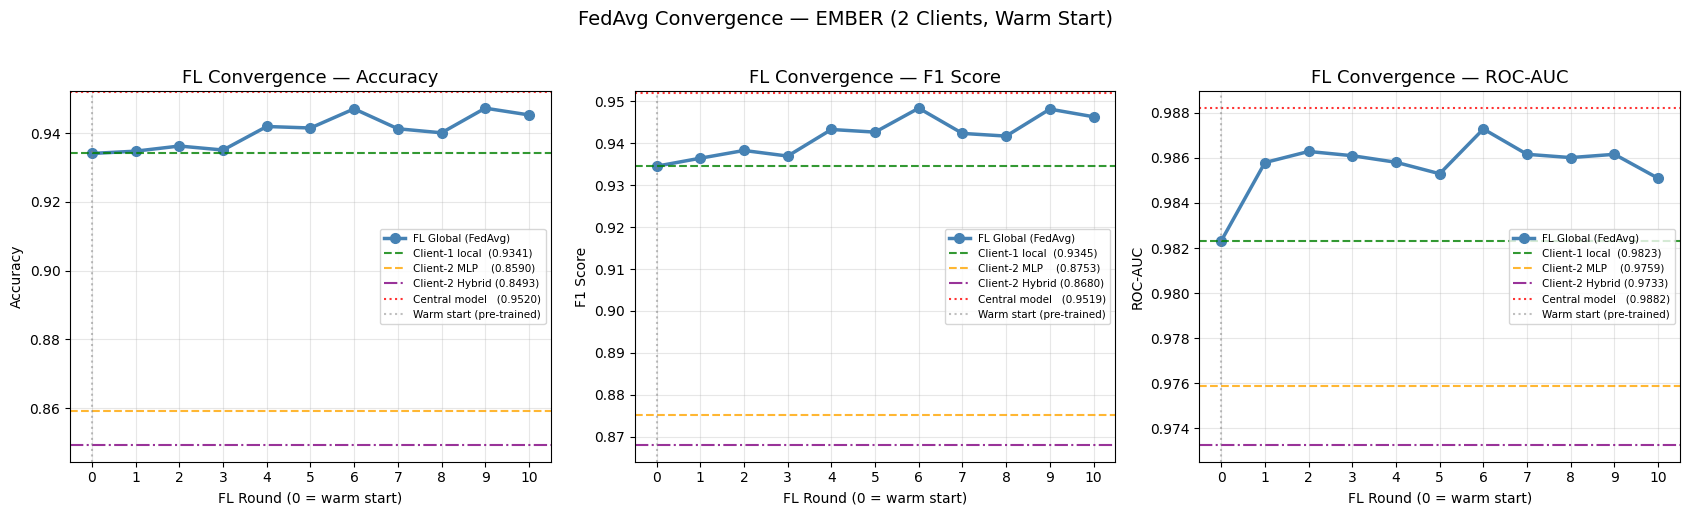

In [15]:
# Cell 12 — Convergence Plots
history_df = pd.DataFrame(history)
CENTRAL_FIXED = {'accuracy': 0.9520, 'f1': 0.9519, 'roc_auc': 0.9882}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metrics_cfg = [('accuracy', 'Accuracy'), ('f1', 'F1 Score'), ('roc_auc', 'ROC-AUC')]

for ax, (metric, title) in zip(axes, metrics_cfg):
    ax.plot(history_df['round'], history_df[metric],
            marker='o', linewidth=2.5, markersize=7,
            color='steelblue', label='FL Global (FedAvg)')

    ax.axhline(y=c1_metrics_pre[metric], color='green',  linestyle='--', alpha=0.8,
               label=f"Client-1 local  ({c1_metrics_pre[metric]:.4f})")
    ax.axhline(y=c2_metrics_mlp_pre[metric], color='orange', linestyle='--', alpha=0.8,
               label=f"Client-2 MLP    ({c2_metrics_mlp_pre[metric]:.4f})")
    ax.axhline(y=c2_metrics_hybrid_pre[metric], color='purple', linestyle='-.', alpha=0.8,
               label=f"Client-2 Hybrid ({c2_metrics_hybrid_pre[metric]:.4f})")
    ax.axhline(y=CENTRAL_FIXED[metric], color='red', linestyle=':', alpha=0.8,
               label=f"Central model   ({CENTRAL_FIXED[metric]:.4f})")

    ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5, label='Warm start (pre-trained)')
    ax.set_title(f'FL Convergence — {title}', fontsize=13)
    ax.set_xlabel('FL Round (0 = warm start)')
    ax.set_ylabel(title)
    ax.set_xticks(range(0, NUM_ROUNDS + 1))
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.3)

plt.suptitle('FedAvg Convergence — EMBER (2 Clients, Warm Start)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("fedavg_convergence_warmstart.png", dpi=150, bbox_inches='tight')
plt.show()

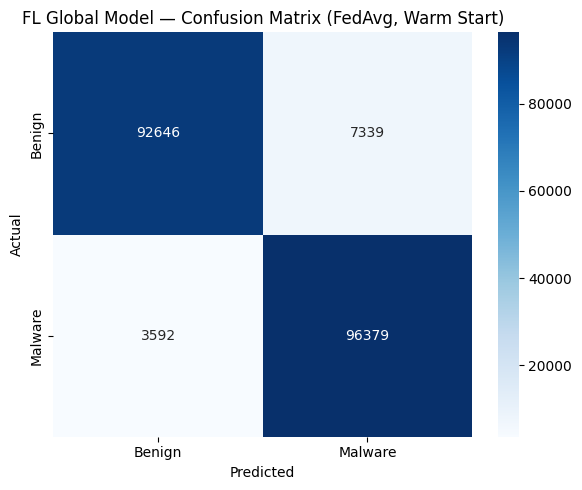

              precision    recall  f1-score   support

      Benign       0.96      0.93      0.94     99985
     Malware       0.93      0.96      0.95     99971

    accuracy                           0.95    199956
   macro avg       0.95      0.95      0.95    199956
weighted avg       0.95      0.95      0.95    199956



In [16]:
# Cell 13 — Confusion Matrix
global_final_model = build_mlp(INPUT_DIM)
global_final_model.set_weights(global_weights)

y_prob_fl = global_final_model.predict(X_test_scaled, verbose=0).ravel()
y_pred_fl = (y_prob_fl > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_fl)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Benign", "Malware"],
            yticklabels=["Benign", "Malware"])
plt.title("FL Global Model — Confusion Matrix (FedAvg, Warm Start)")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("fedavg_confusion_matrix.png", dpi=150)
plt.show()

print(classification_report(y_test, y_pred_fl, target_names=["Benign", "Malware"]))

In [17]:
# Cell 14 — Save All Artifacts
import json

# Save last round global model
global_final_model = build_mlp(INPUT_DIM)
global_final_model.set_weights(global_weights)
global_final_model.save("ember_fedavg_global_last.keras")

# Save best round model (already saved in 11b)
# ember_fedavg_best.keras  ← already done

# Save round history
history_df = pd.DataFrame(history)
history_df.to_csv("fedavg_round_history.csv", index=False)

# Save comparison
comparison_df.to_csv("fedavg_comparison.csv", index=False)

# Save best round metadata
best_info = {
    "best_round":    best_round_num,
    "best_f1":       round(best_f1, 4),
    "best_accuracy": round(best_metrics['accuracy'], 4),
    "best_roc_auc":  round(best_metrics['roc_auc'], 4),
    "num_rounds":    NUM_ROUNDS,
    "local_epochs":  LOCAL_EPOCHS,
    "num_clients":   2,
    "data_sizes":    DATA_SIZES
}

with open("fedavg_best_info.json", "w") as f:
    json.dump(best_info, f, indent=2)

print("✅ Saved:")
print(f"   ember_fedavg_best.keras          ← Best model (Round {best_round_num})")
print( "   ember_fedavg_global_last.keras   ← Last round model")
print( "   fedavg_round_history.csv         ← Per-round metrics")
print( "   fedavg_comparison.csv            ← Final comparison table")
print( "   fedavg_best_info.json            ← Best round metadata")
print( "   fedavg_convergence_warmstart.png ← Convergence plots")
print( "   fedavg_confusion_matrix.png      ← Confusion matrix")

✅ Saved:
   ember_fedavg_best.keras          ← Best model (Round 6)
   ember_fedavg_global_last.keras   ← Last round model
   fedavg_round_history.csv         ← Per-round metrics
   fedavg_comparison.csv            ← Final comparison table
   fedavg_best_info.json            ← Best round metadata
   fedavg_convergence_warmstart.png ← Convergence plots
   fedavg_confusion_matrix.png      ← Confusion matrix
